In [1]:
import math
import os
import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import torch


def locate_project_root(start: Path | None = None) -> Path:
    cursor = (start or Path.cwd()).resolve()
    for candidate in [cursor, *cursor.parents]:
        if (candidate / "data").exists() and (candidate / "test_notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root that contains both data/ and test_notebooks/.")


PROJECT_ROOT = locate_project_root()
os.chdir(PROJECT_ROOT)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eps = 1e-12
_LEN_PATTERN = re.compile(r"_len_(\d+)_pfN_")

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")


@dataclass
class ExperimentConfig:
    name: str
    dataset: str
    sigma_y: float
    input_len: int
    output_len: int | None = None
    batch_size: int = 64
    dt: float = 0.15
    pf_N_list: Sequence[int] = field(default_factory=list)
    seed_list: Sequence[int] = field(default_factory=list)
    max_t_list: Sequence[int] = field(default_factory=list)
    len_candidates: Sequence[int] = field(default_factory=list)
    save_avg: bool = True
    verbose: bool = True

    def __post_init__(self) -> None:
        if self.output_len is None:
            self.output_len = self.input_len

    @property
    def data_dir(self) -> Path:
        return PROJECT_ROOT / "data" / self.dataset


def _sigma_aliases(sigma_y: float) -> list[str]:
    aliases = {str(sigma_y)}
    try:
        sigma_float = float(sigma_y)
        aliases.add(f"{sigma_float:.1f}")
        if sigma_float.is_integer():
            aliases.add(str(int(sigma_float)))
    except (TypeError, ValueError):
        pass
    return sorted(aliases)


def _parse_len(path: Path) -> int | None:
    matched = _LEN_PATTERN.search(path.name)
    return int(matched.group(1)) if matched else None


def _build_file_name(sigma_str: str, batch_size: int, seq_len: int, pf_N: int, seed: int) -> str:
    return f"pf_results_sigma_y_{sigma_str}_batch_{batch_size}_len_{seq_len}_pfN_{pf_N}_{seed}.pt"


def resolve_seed_file(cfg: ExperimentConfig, pf_N: int, seed: int) -> tuple[Path | None, bool]:
    sigma_opts = _sigma_aliases(cfg.sigma_y)
    len_opts = [cfg.input_len, *cfg.len_candidates]

    for sigma_str in sigma_opts:
        for seq_len in len_opts:
            candidate = cfg.data_dir / _build_file_name(sigma_str, cfg.batch_size, seq_len, pf_N, seed)
            if candidate.exists():
                return candidate, False

    fallback_matches: list[Path] = []
    for sigma_str in sigma_opts:
        pattern = f"pf_results_sigma_y_{sigma_str}_batch_{cfg.batch_size}_len_*_pfN_{pf_N}_{seed}.pt"
        fallback_matches.extend(cfg.data_dir.glob(pattern))

    if not fallback_matches:
        return None, False

    deduped = sorted(set(fallback_matches), key=lambda p: (abs((_parse_len(p) or cfg.input_len) - cfg.input_len), p.name))
    return deduped[0], True


def load_mean_cov(file_path: Path, map_to_device: torch.device) -> tuple[torch.Tensor, torch.Tensor]:
    data = torch.load(file_path, weights_only=True, map_location=map_to_device)
    entry = data[0]

    mean = entry.get("means") if isinstance(entry, dict) else None
    cov = entry.get("covs") if isinstance(entry, dict) else None

    if mean is None and isinstance(entry, dict):
        mean = entry.get("post_means")
    if cov is None and isinstance(entry, dict):
        cov = entry.get("post_covs")

    if mean is None or cov is None:
        raise KeyError(f"Missing mean/cov keys in {file_path.name}")

    return mean, cov


Project root: /home/bhchen/LearnKalmanGain
Device: cuda


In [2]:
def compute_ci_metrics(mean_tensor: torch.Tensor, cov_tensor: torch.Tensor, max_t: int, eps_value: float = 1e-12) -> dict[str, float]:
    n_seeds = mean_tensor.shape[0]
    if n_seeds < 2:
        return {
            "se_rmse_mean": float("nan"),
            "se_rrmse_mean": float("nan"),
            "se_f2_cov": float("nan"),
            "se_rf2_cov": float("nan"),
        }

    max_t_eff = min(max_t, mean_tensor.shape[1], cov_tensor.shape[1])
    mean_t = mean_tensor[:, :max_t_eff]
    cov_t = cov_tensor[:, :max_t_eff]

    avg_mean = torch.mean(mean_t, dim=0, keepdim=True)
    error_mean = mean_t - avg_mean
    std_mean = torch.sqrt(torch.sum(error_mean ** 2, dim=0) / (n_seeds - 1))
    se_mean = std_mean / math.sqrt(n_seeds)
    ci95_mean = 1.96 * se_mean

    ci95_rmse = torch.sqrt(torch.mean(ci95_mean ** 2, dim=-1))
    se_rmse_mean = ci95_rmse.mean().item()

    mean_scale = torch.sqrt(torch.mean(avg_mean.squeeze(0) ** 2, dim=-1))
    se_rrmse_mean = (ci95_rmse / (mean_scale + eps_value)).mean().item()

    avg_cov = torch.mean(cov_t, dim=0, keepdim=True)
    error_cov = cov_t - avg_cov
    std_cov = torch.sqrt(torch.sum(error_cov ** 2, dim=0) / (n_seeds - 1))
    se_cov = std_cov / math.sqrt(n_seeds)
    ci95_cov = 1.96 * se_cov

    ci95_cov_fro = torch.linalg.norm(ci95_cov, ord="fro", dim=(-2, -1))
    se_f2_cov = ci95_cov_fro.mean().item()

    cov_scale = torch.linalg.norm(avg_cov.squeeze(0), ord="fro", dim=(-2, -1))
    se_rf2_cov = (ci95_cov_fro / (cov_scale + eps_value)).mean().item()

    return {
        "se_rmse_mean": se_rmse_mean,
        "se_rrmse_mean": se_rrmse_mean,
        "se_f2_cov": se_f2_cov,
        "se_rf2_cov": se_rf2_cov,
    }


def _save_avg_file(cfg: ExperimentConfig, pf_N: int, mean_tensor: torch.Tensor, cov_tensor: torch.Tensor) -> Path:
    cfg.data_dir.mkdir(parents=True, exist_ok=True)
    sigma_str = f"{float(cfg.sigma_y):.1f}"
    out_file = cfg.data_dir / (
        f"pf_results_sigma_y_{sigma_str}_batch_{cfg.batch_size}_len_{cfg.output_len}_pfN_{pf_N}_avg.pt"
    )
    torch.save([{"means": mean_tensor.mean(dim=0), "covs": cov_tensor.mean(dim=0)}], out_file)
    return out_file


def _plot_experiment(cfg: ExperimentConfig, metrics_by_t: dict[int, dict[str, list[float]]]) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plot_items = [
        (0, 0, "se_rmse_mean", "SE of mean (RMSE, 95% CI)"),
        (0, 1, "se_f2_cov", "SE of cov (F-norm, 95% CI)"),
        (1, 0, "se_rrmse_mean", "SE of mean (RRMSE, 95% CI)"),
        (1, 1, "se_rf2_cov", "SE of cov (RF2, 95% CI)"),
    ]

    for max_t, metric_dict in metrics_by_t.items():
        label = fr"T={max_t * cfg.dt:.2f} ($\Delta t$={cfg.dt})"
        for r, c, key, ylabel in plot_items:
            ax = axes[r, c]
            ax.plot(cfg.pf_N_list, metric_dict[key], marker="o", linestyle="-", label=label)
            ax.set_xscale("log")
            ax.set_xlabel("number of particles")
            ax.set_ylabel(ylabel)
            ax.grid(True, which="both", ls="--")

    fig.suptitle(cfg.name)
    for ax in axes.flatten():
        ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


def run_experiment(cfg: ExperimentConfig, map_to_device: torch.device = device, eps_value: float = eps) -> dict:
    print(f"\n=== {cfg.name} ===")
    print(f"Data dir: {cfg.data_dir}")

    per_pf_data: dict[int, dict[str, object]] = {}

    for pf_N in cfg.pf_N_list:
        mean_list: list[torch.Tensor] = []
        cov_list: list[torch.Tensor] = []
        missing_seeds: list[int] = []
        fallback_files: list[str] = []

        for seed in cfg.seed_list:
            file_path, used_fallback = resolve_seed_file(cfg, pf_N, seed)
            if file_path is None:
                missing_seeds.append(seed)
                continue

            try:
                mean_tensor, cov_tensor = load_mean_cov(file_path, map_to_device)
                mean_list.append(mean_tensor)
                cov_list.append(cov_tensor)
                if used_fallback:
                    fallback_files.append(file_path.name)
            except Exception as exc:
                print(f"Could not load {file_path}: {exc}")

        if not mean_list:
            print(f"pf_N={pf_N}: no usable files, skipped.")
            continue

        mean_tensor = torch.stack(mean_list)
        cov_tensor = torch.stack(cov_list)

        if cfg.save_avg:
            avg_file = _save_avg_file(cfg, pf_N, mean_tensor, cov_tensor)
            if cfg.verbose:
                print(f"Saved avg: {avg_file.name}")

        if cfg.verbose:
            print(f"pf_N={pf_N}: loaded {len(mean_list)} seeds, missing {len(missing_seeds)}")
            if fallback_files:
                print(f"  used len fallback for {len(fallback_files)} files")

        per_pf_data[pf_N] = {
            "mean_tensor": mean_tensor,
            "cov_tensor": cov_tensor,
            "n_loaded": len(mean_list),
            "missing_seeds": missing_seeds,
            "fallback_files": fallback_files,
        }

    metrics_by_t: dict[int, dict[str, list[float]]] = {}
    for max_t in cfg.max_t_list:
        stats = {
            "se_rmse_mean": [],
            "se_rrmse_mean": [],
            "se_f2_cov": [],
            "se_rf2_cov": [],
        }
        for pf_N in cfg.pf_N_list:
            run_data = per_pf_data.get(pf_N)
            if run_data is None:
                for key in stats:
                    stats[key].append(float("nan"))
                continue

            metric = compute_ci_metrics(
                run_data["mean_tensor"],
                run_data["cov_tensor"],
                max_t=max_t,
                eps_value=eps_value,
            )
            for key in stats:
                stats[key].append(metric[key])

        metrics_by_t[max_t] = stats

    _plot_experiment(cfg, metrics_by_t)
    return {"config": cfg, "per_pf_data": per_pf_data, "metrics_by_t": metrics_by_t}


In [8]:
COMMON_PF_N = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
COMMON_MAX_T = [100, 300, 500]
SEEDS_11 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
SEEDS_12 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 42]
SEEDS_100 = list(range(100))

EXPERIMENTS = {
    "lorenz63_sigma_1.0": ExperimentConfig(
        name="Lorenz63 (sigma_y=1.0)",
        dataset="lorenz63",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=COMMON_MAX_T,
    ),
    "rossler_sigma_1.0": ExperimentConfig(
        name="Rossler (sigma_y=1.0)",
        dataset="rossler",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=[1000, 2000, 5000, 10000, 20000, 50000, 100000],
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "lorenz96_sigma_1.0": ExperimentConfig(
        name="Lorenz96 (sigma_y=1.0)",
        dataset="lorenz96",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "circle_sigma_1.0": ExperimentConfig(
        name="Circle (sigma_y=1.0)",
        dataset="circle",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "hdoublewell_sigma_1.0": ExperimentConfig(
        name="HDoublewell (sigma_y=1.0)",
        dataset="Hdoublewell",
        sigma_y=1.0,
        input_len=500,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_100,
        max_t_list=COMMON_MAX_T,
    ),
    "doubling1d_sigma_0.1": ExperimentConfig(
        name="Doubling1D (sigma_y=0.1)",
        dataset="doubling1d",
        sigma_y=0.2,
        input_len=200,
        output_len=200,
        pf_N_list=COMMON_PF_N,
        seed_list=SEEDS_11,
        max_t_list=[100, 200],
        len_candidates=[500],
    ),
    "complex2d_sigma_0.1": ExperimentConfig(
        name="Complex2D (sigma_y=0.1)",
        dataset="complex2d",
        sigma_y=0.2,
        input_len=200,
        output_len=200,
        pf_N_list=[500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000],
        seed_list=SEEDS_12,
        max_t_list=[100, 200],
    ),
}

print("Available experiment keys:")
for key in EXPERIMENTS:
    print(f"- {key}")


Available experiment keys:
- lorenz63_sigma_1.0
- rossler_sigma_1.0
- lorenz96_sigma_1.0
- circle_sigma_1.0
- hdoublewell_sigma_1.0
- doubling1d_sigma_0.1
- complex2d_sigma_0.1



=== Lorenz63 (sigma_y=1.0) ===
Data dir: /home/bhchen/LearnKalmanGain/data/lorenz63
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
pf_N=1000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
pf_N=2000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
pf_N=5000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
pf_N=10000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
pf_N=20000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
pf_N=50000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt
pf_N=100000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_200000_avg.pt
pf_N=200000: loaded 11 seeds, missing 0
Saved avg: pf_results_sigma_y_1.0_batch_64_len_500_pfN_500000

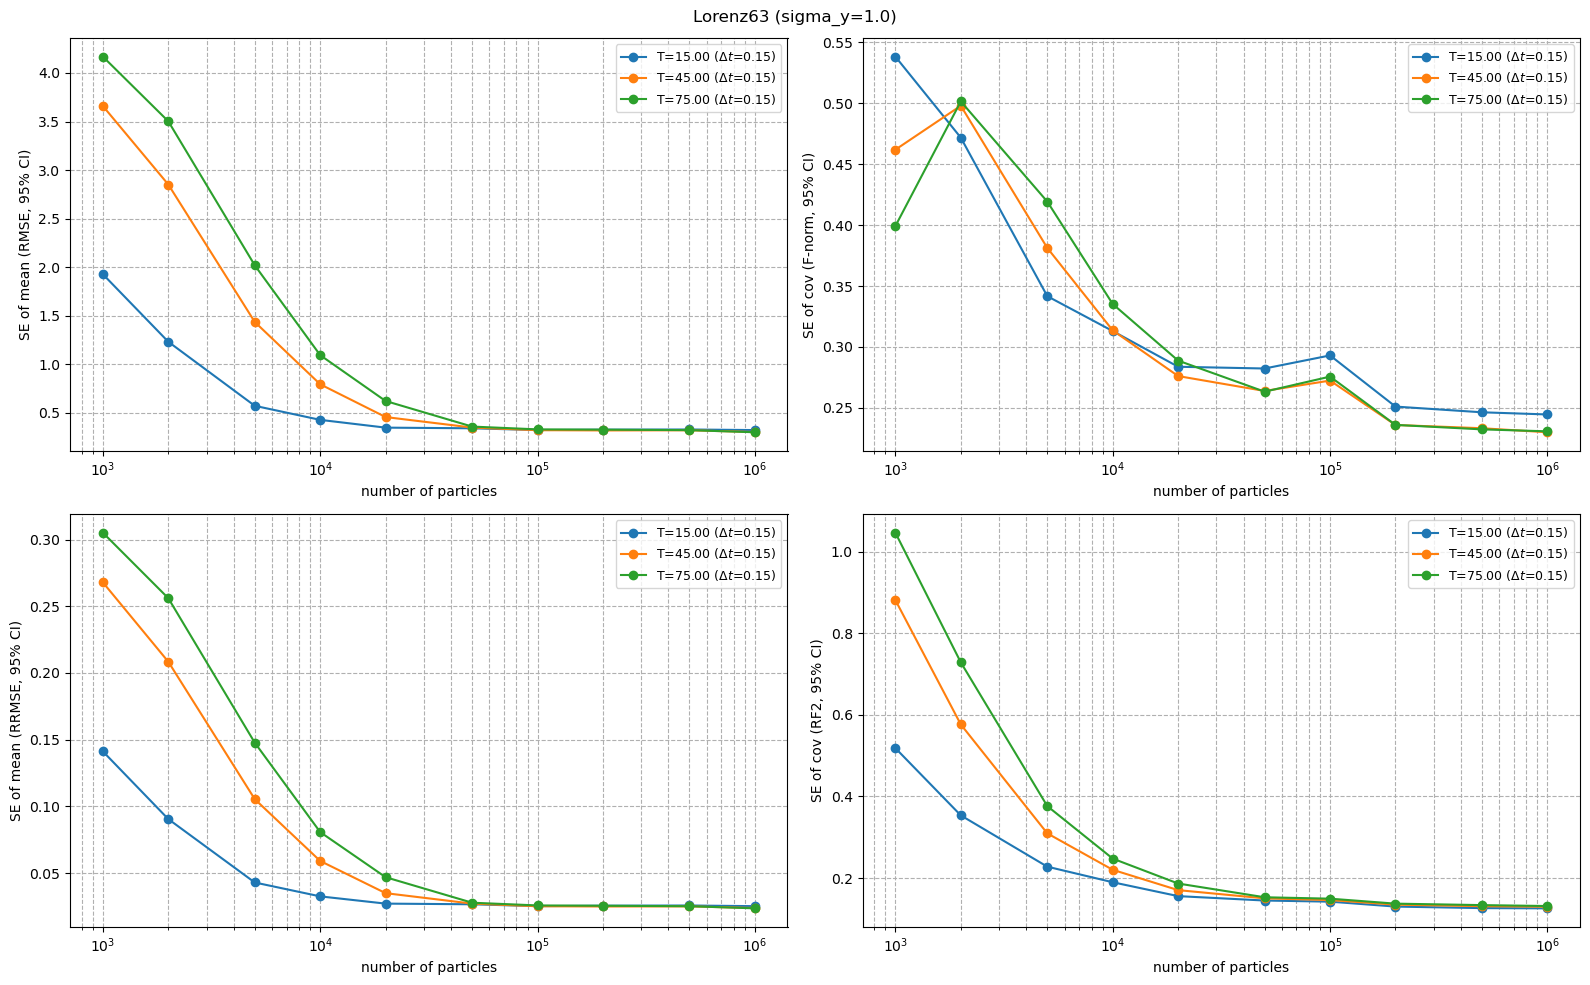


Done. Results stored in `results`.


In [9]:
SELECTED_EXPERIMENTS = [
    "lorenz63_sigma_1.0",
    # "rossler_sigma_1.0",
    # "lorenz96_sigma_1.0",
    # "circle_sigma_1.0",
    # "hdoublewell_sigma_1.0",
    # "doubling1d_sigma_0.1",
    # "complex2d_sigma_0.1",
]

results = {}
for exp_key in SELECTED_EXPERIMENTS:
    cfg = EXPERIMENTS[exp_key]
    results[exp_key] = run_experiment(cfg)

print("\nDone. Results stored in `results`.")
